In [467]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy.stats import probplot
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
# hide warnings
import warnings
warnings.filterwarnings('ignore')

In [469]:
data=pd.read_csv("CarPrice_Assignment.csv")
data

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [471]:
data.shape
print(data.info())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

The dataset had no missing values.

Draw some basic plot like histogram,barplot and draw scatter plot for check the relationship between predictor variables and target variables.

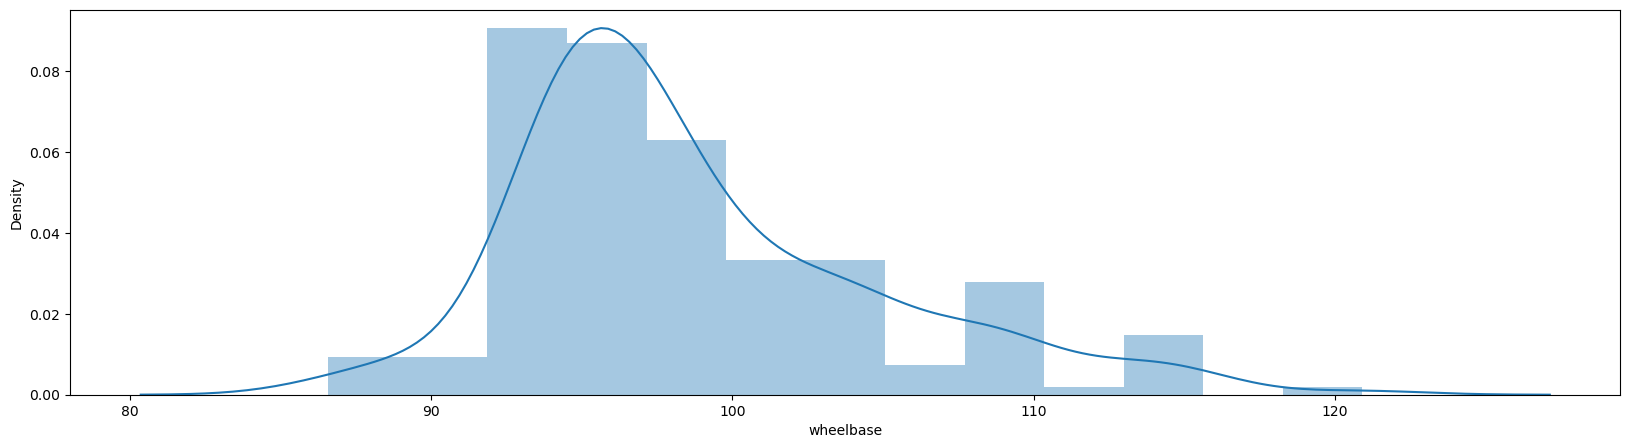

None


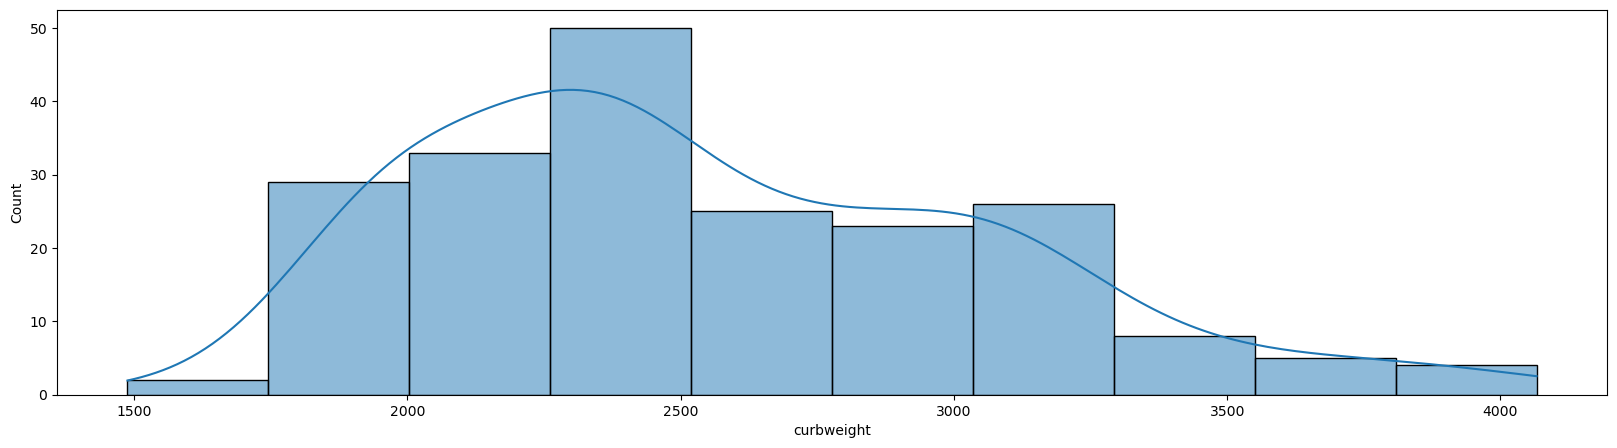

None


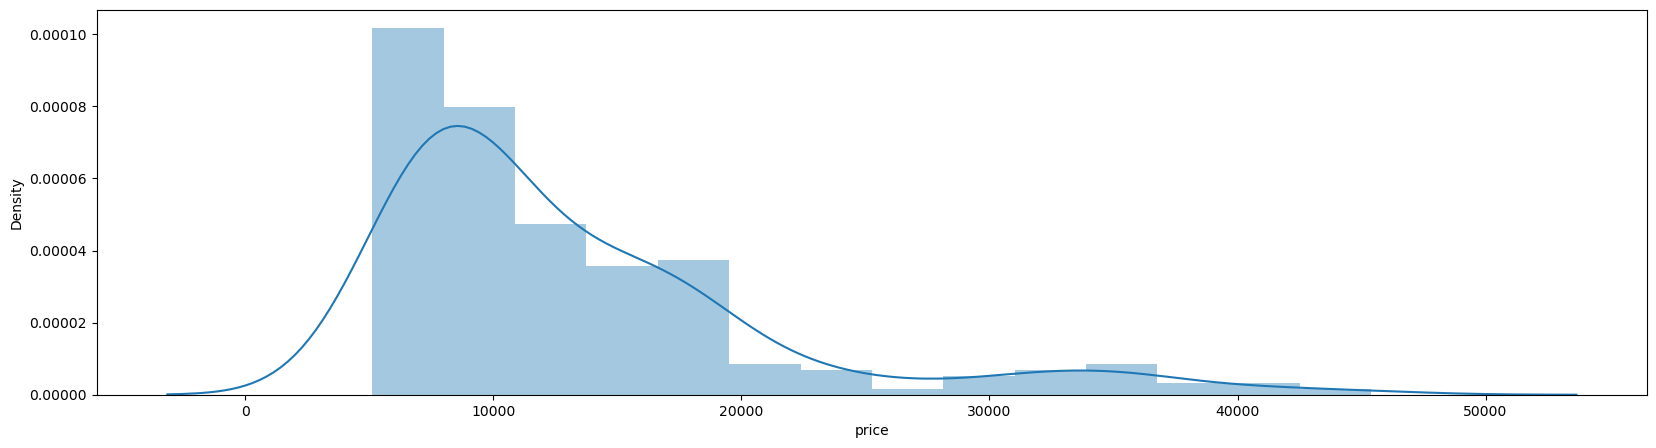

In [473]:
plt.figure(figsize=(20,5))
sns.distplot(data['wheelbase'])
print(plt.show())
plt.figure(figsize=(20,5))
sns.histplot(data['curbweight'],kde=True)
print(plt.show())
plt.figure(figsize=(20,5))
sns.distplot(data['price'],kde=True)
plt.show()


Axes(0.125,0.11;0.775x0.77)


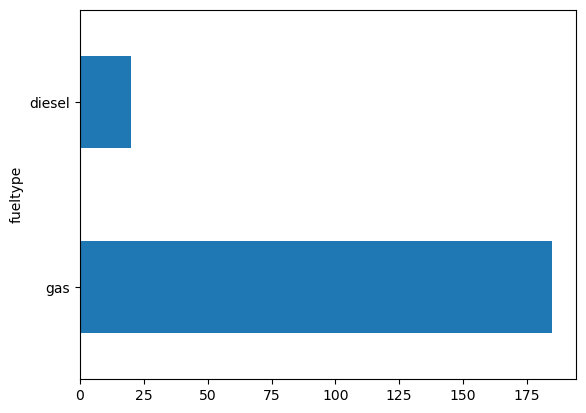

In [475]:
print(data["fueltype"].value_counts().plot(kind="barh"))

Axes(0.125,0.11;0.775x0.77)


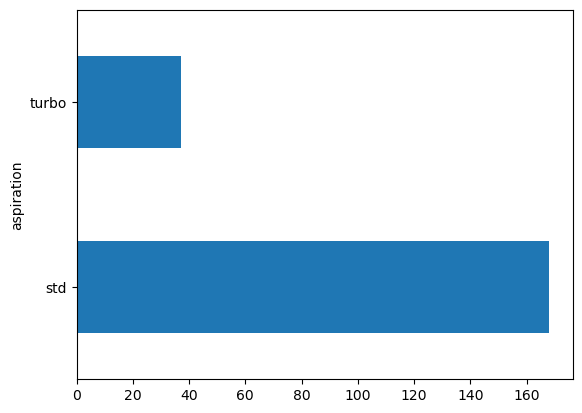

In [477]:
print(data["aspiration"].value_counts().plot(kind="barh"))

Here Car variable  have many model name of car. So we combine the same model and denote its car company name.

CarName
toyota         32
nissan         18
mazda          17
mitsubishi     13
honda          13
volkswagen     12
subaru         12
peugeot        11
volvo          11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
porsche         5
isuzu           4
jaguar          3
chevrolet       3
alfa-romero     3
renault         2
mercury         1
Name: count, dtype: int64


<Axes: ylabel='count'>

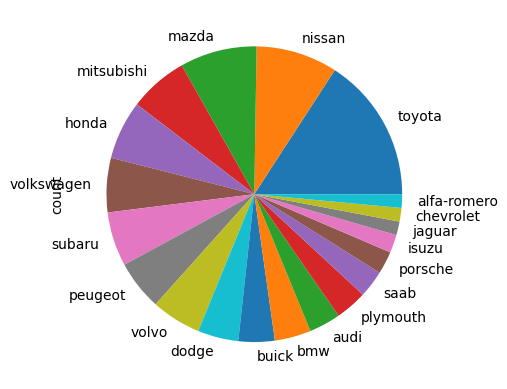

In [479]:
data['CarName'] = data['CarName'].apply(lambda x: x.split(" ")[0])
data.loc[(data['CarName'] == "vw") | 
         (data['CarName'] == "vokswagen")
         , 'CarName'] = 'volkswagen'

# porsche
data.loc[data['CarName'] == "porcshce", 'CarName'] = 'porsche'

# toyota
data.loc[data['CarName'] == "toyouta", 'CarName'] = 'toyota'

# nissan
data.loc[data['CarName'] == "Nissan", 'CarName'] = 'nissan'

# mazda
data.loc[data['CarName'] == "maxda", 'CarName'] = 'mazda'

print(data["CarName"].value_counts())

data['CarName'].value_counts().head(20).plot(kind="pie")


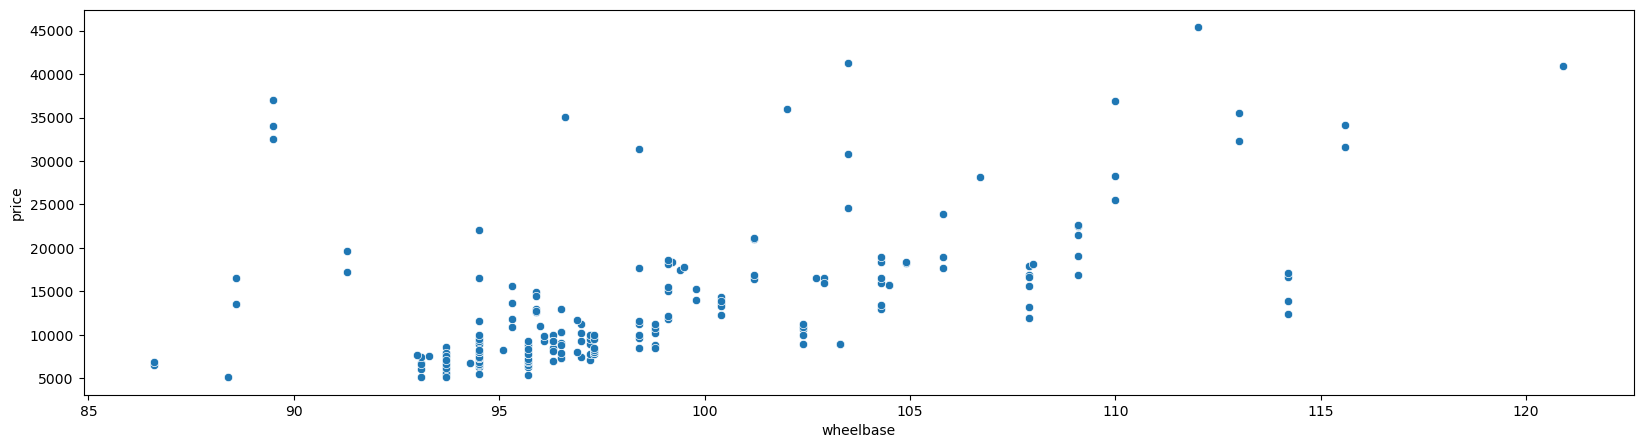

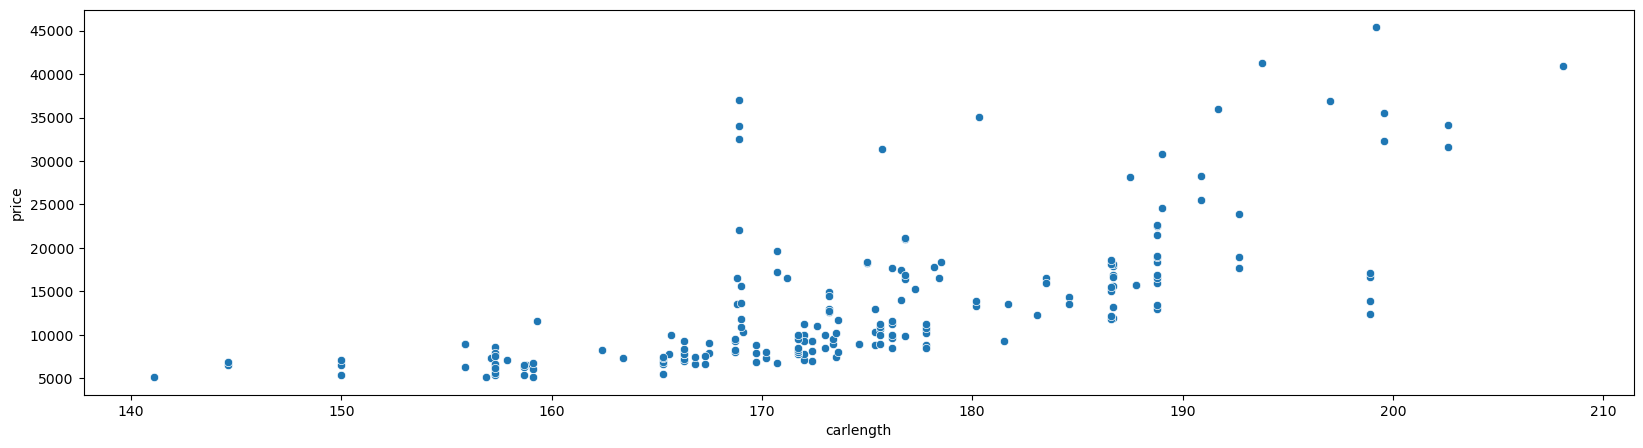

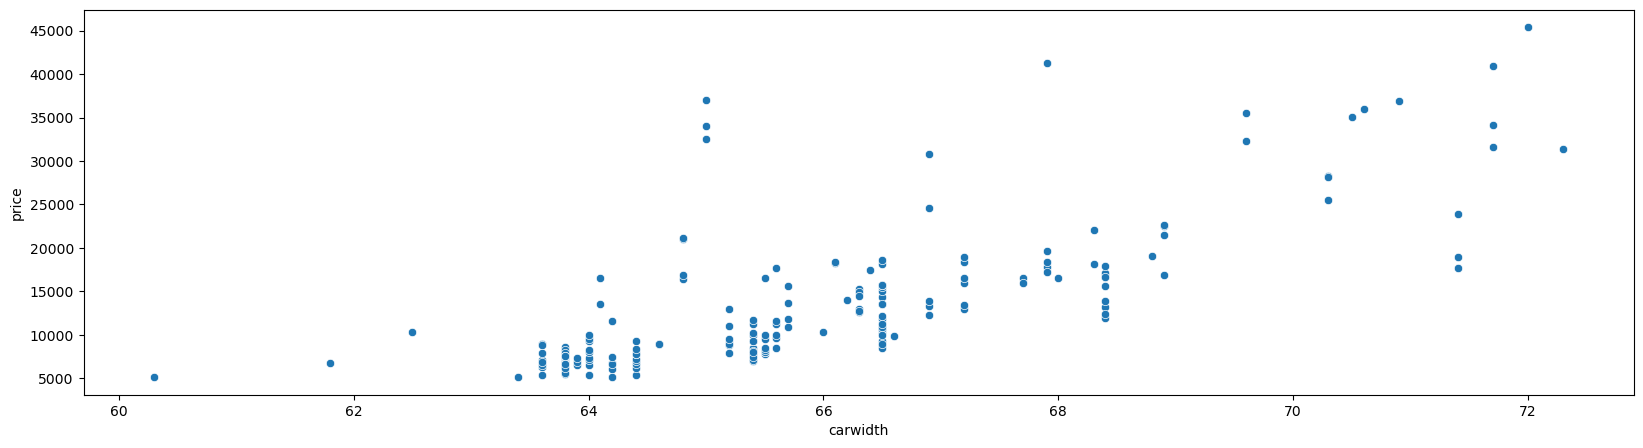

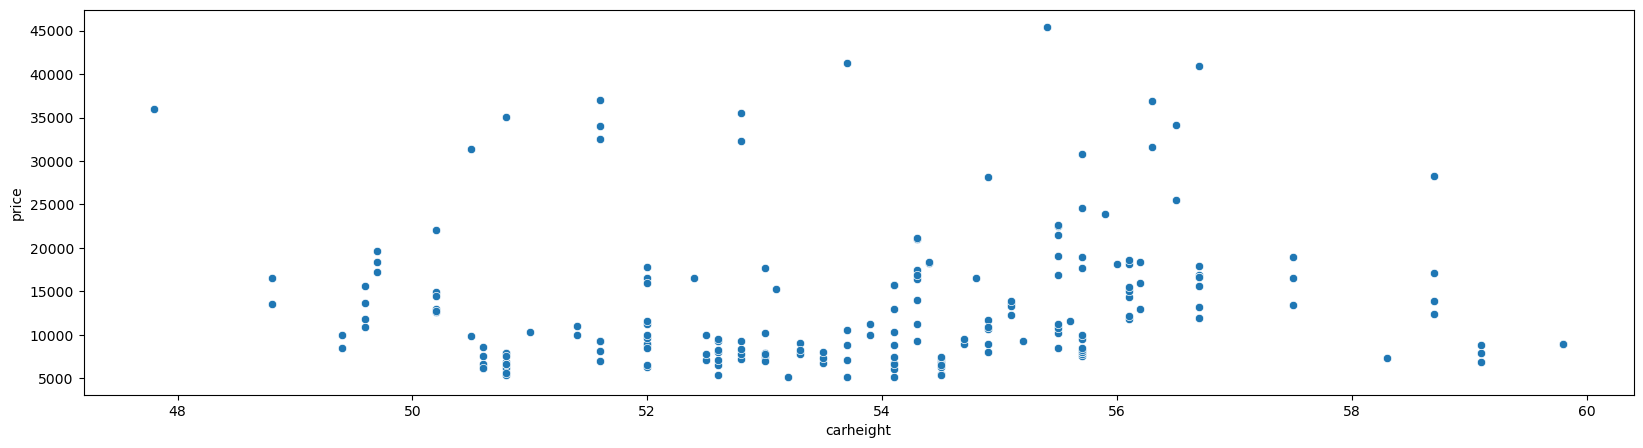

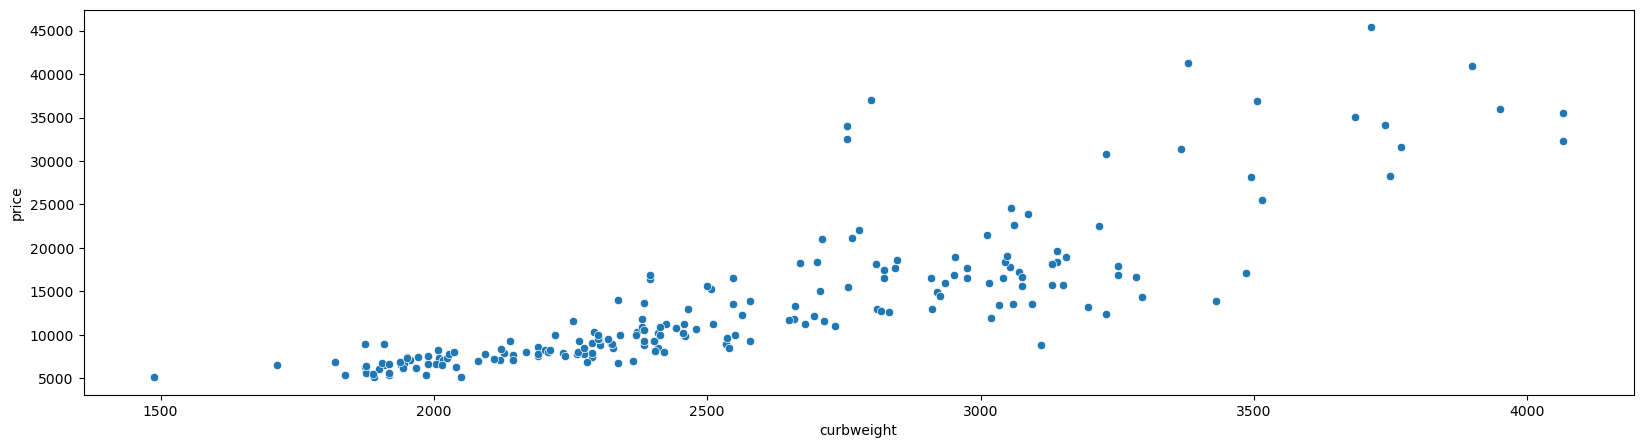

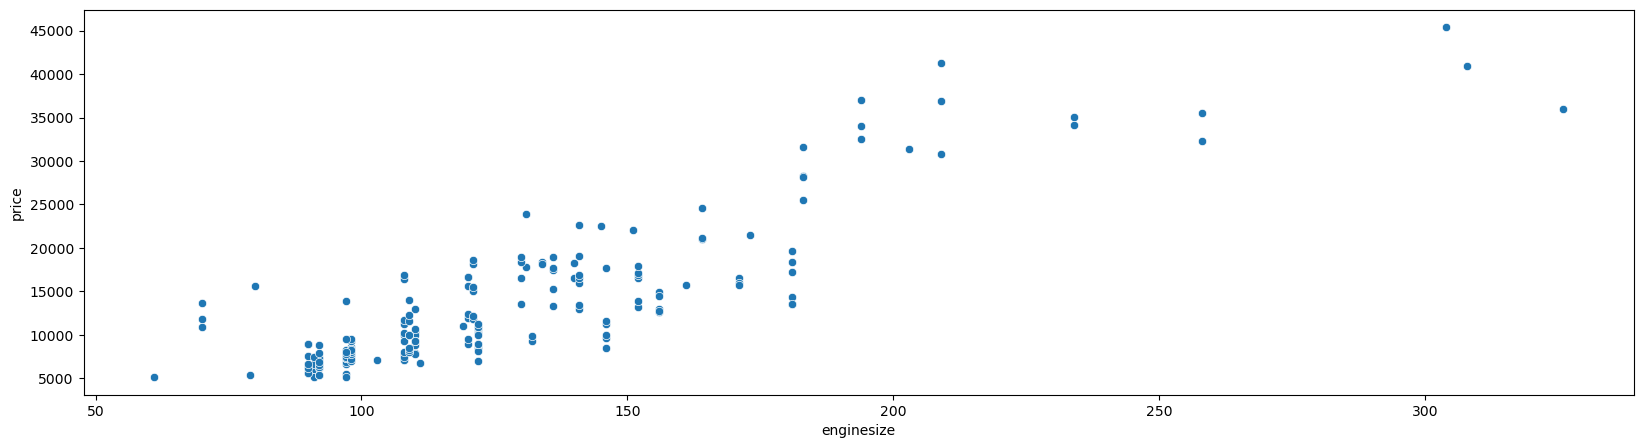

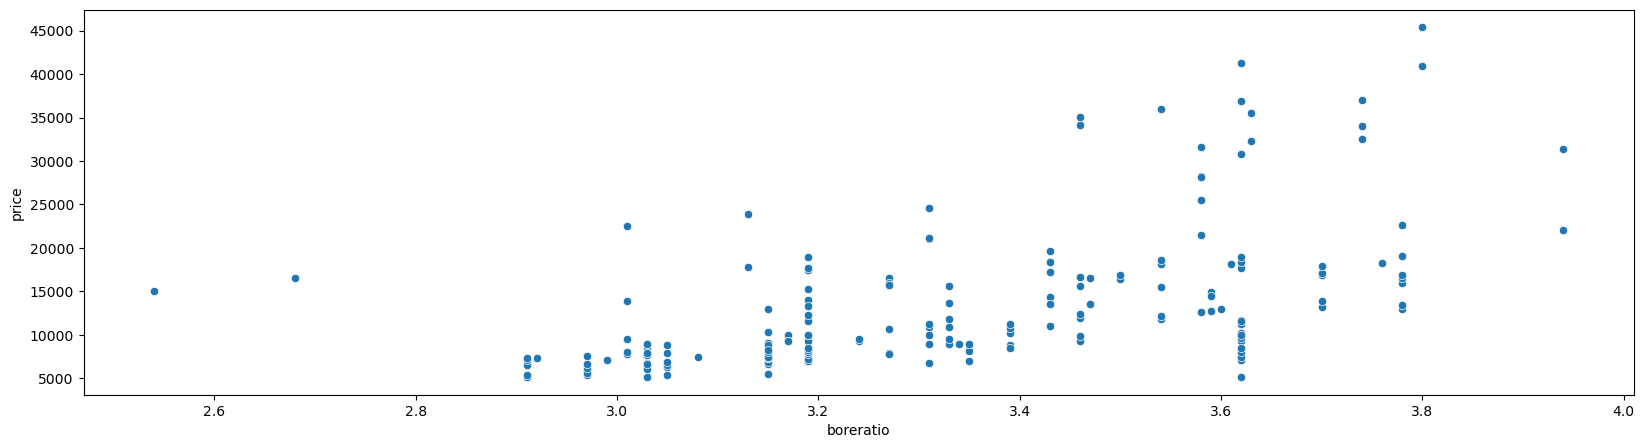

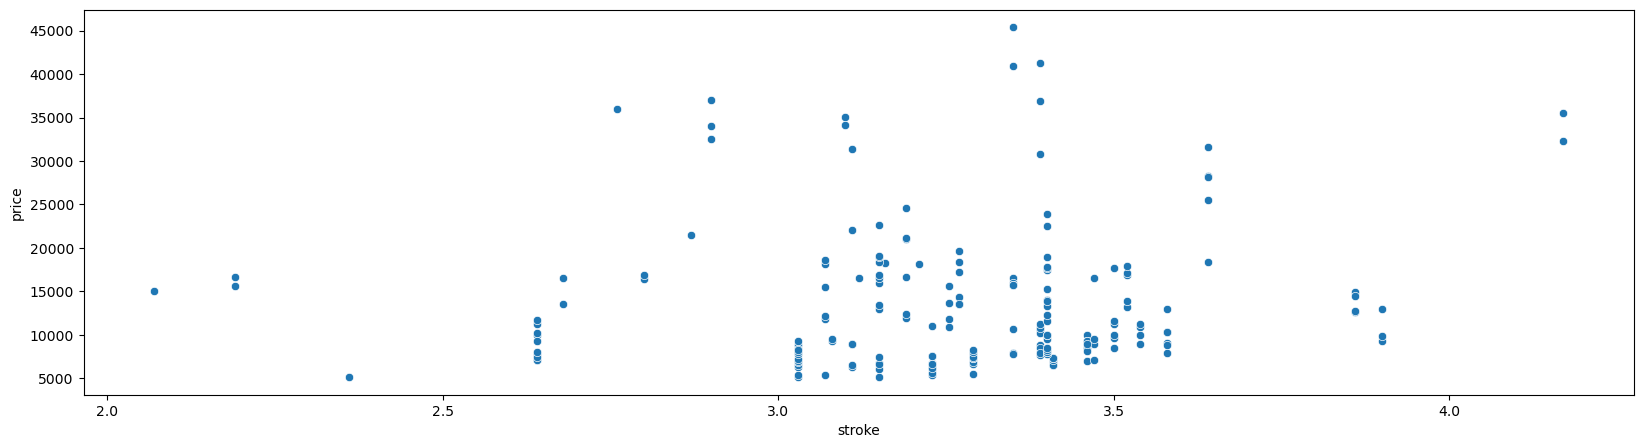

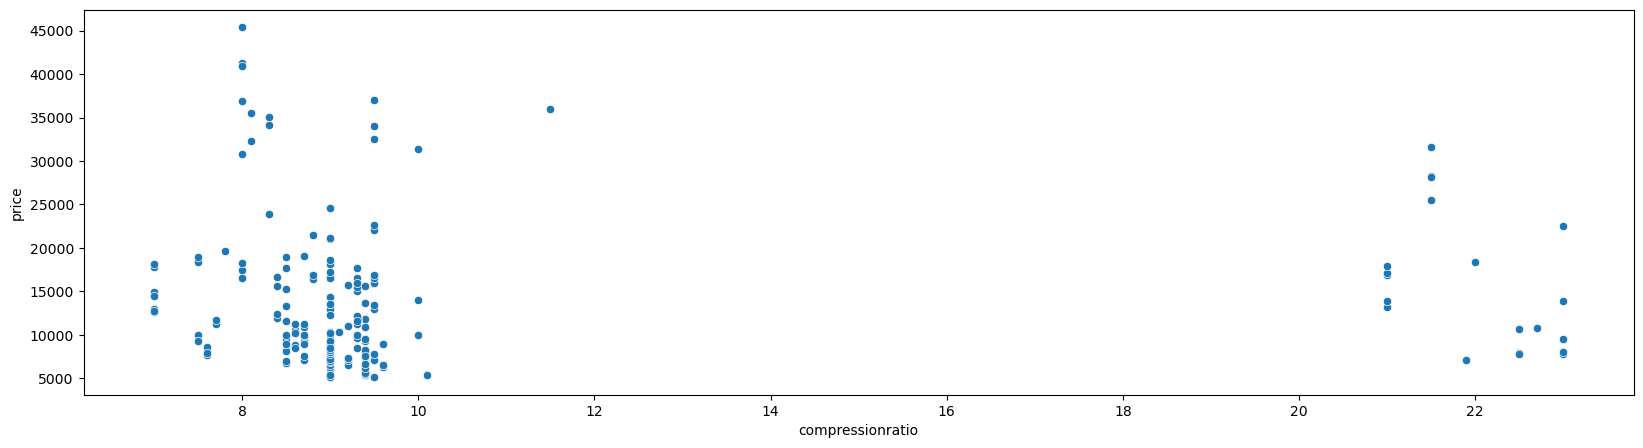

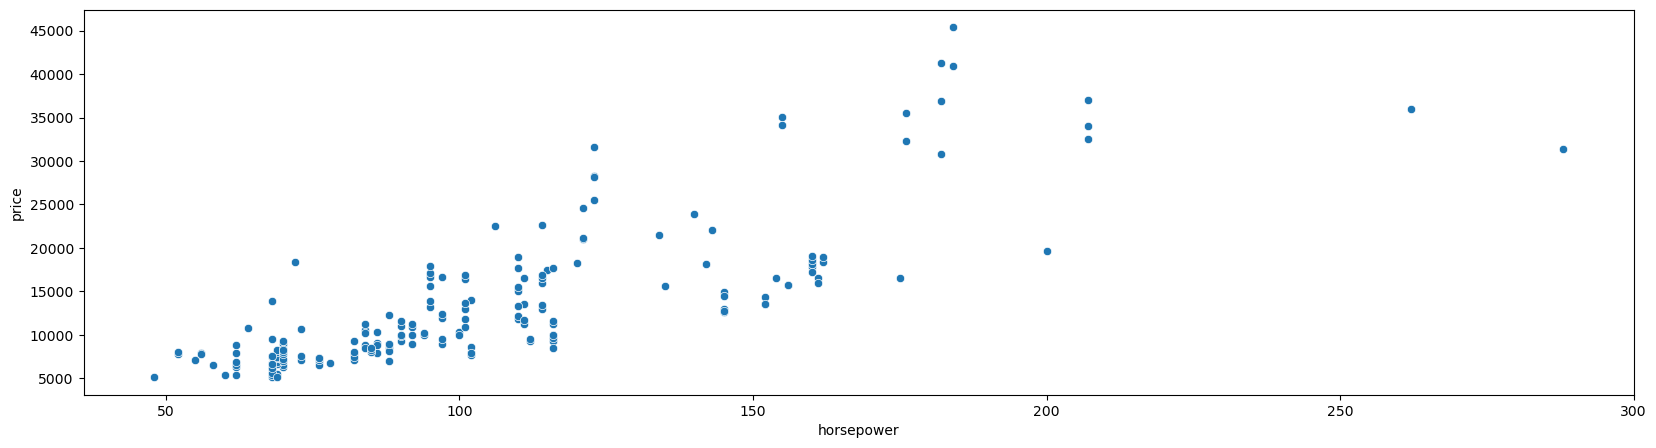

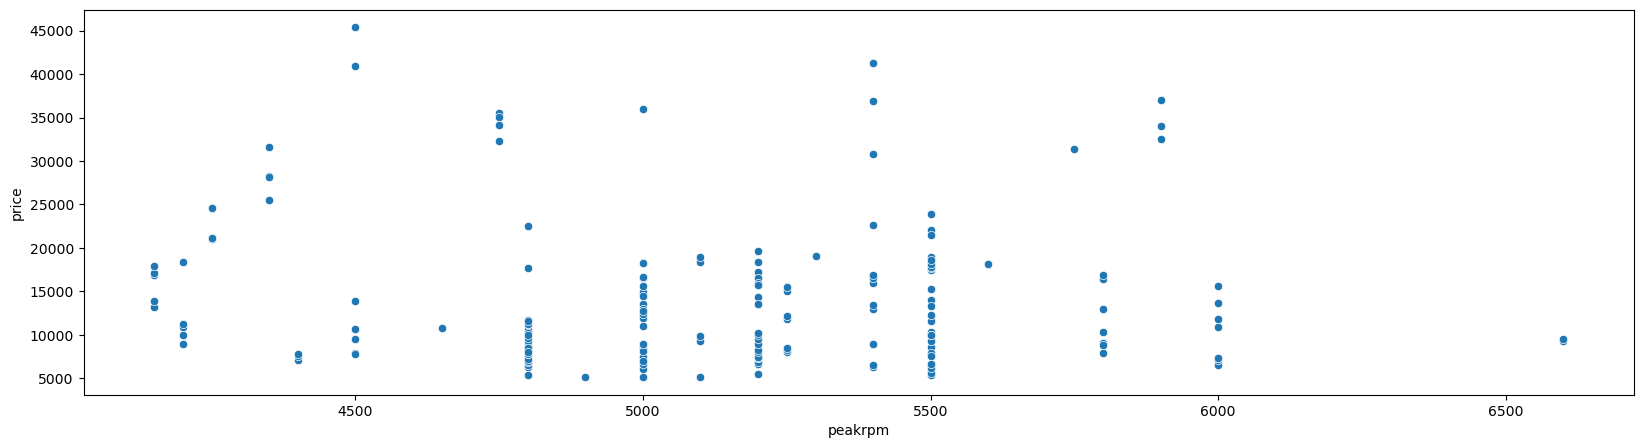

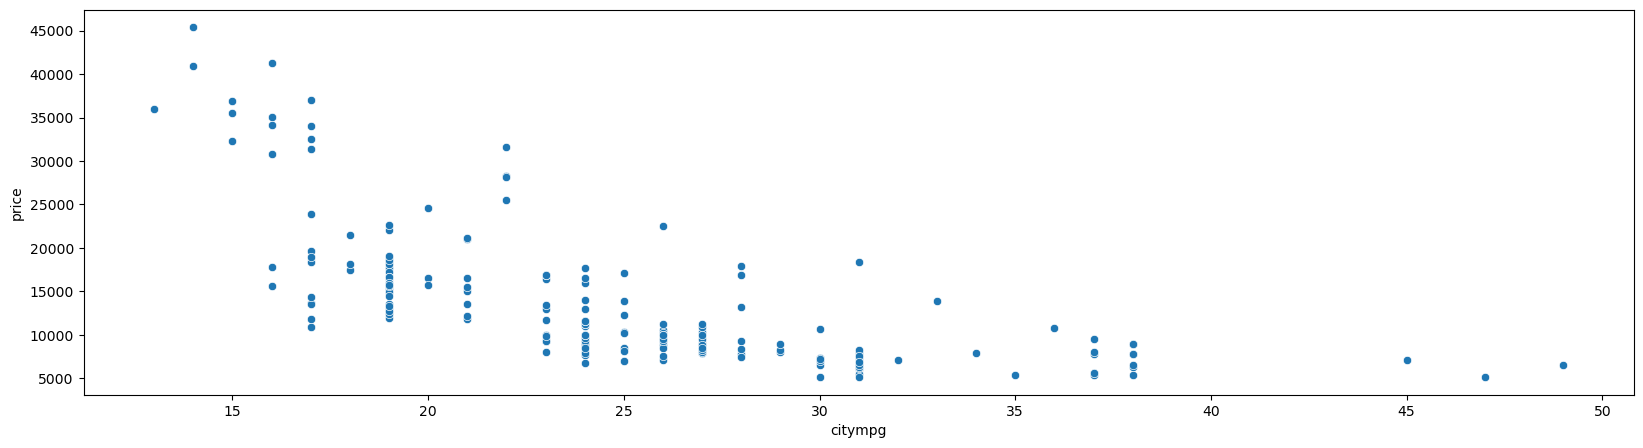

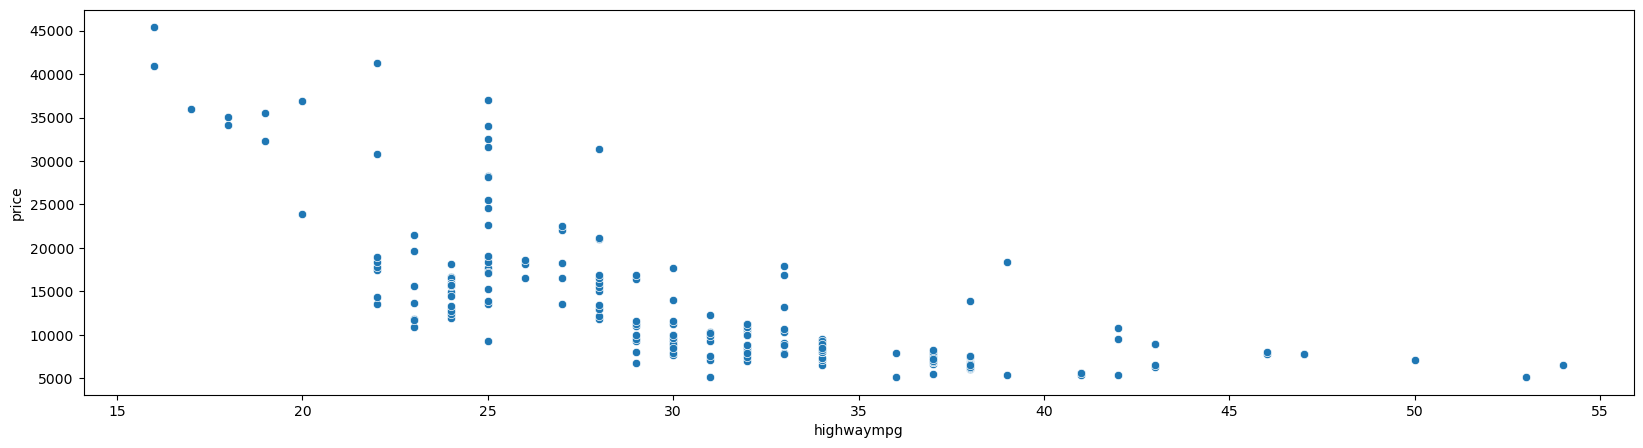

In [481]:
vars_numeric = data.select_dtypes(include=['float', 'int'])
vars_numeric.head()
vars_numeric = vars_numeric.drop(['symboling','car_ID','price'], axis=1)
vars_numeric.head()
for col in vars_numeric:
    plt.figure(figsize=(20,5))
    sns.scatterplot(data=data,x=data[col],y="price")
    

we see target variable and predictor variables have linear relationship.

Let us find the correlation for finding the correlated pairs.

                  wheelbase  carlength  carwidth  carheight  curbweight  \
wheelbase          1.000000   0.874587  0.795144   0.589435    0.776386   
carlength          0.874587   1.000000  0.841118   0.491029    0.877728   
carwidth           0.795144   0.841118  1.000000   0.279210    0.867032   
carheight          0.589435   0.491029  0.279210   1.000000    0.295572   
curbweight         0.776386   0.877728  0.867032   0.295572    1.000000   
enginesize         0.569329   0.683360  0.735433   0.067149    0.850594   
boreratio          0.488750   0.606454  0.559150   0.171071    0.648480   
stroke             0.160959   0.129533  0.182942  -0.055307    0.168790   
compressionratio   0.249786   0.158414  0.181129   0.261214    0.151362   
horsepower         0.353294   0.552623  0.640732  -0.108802    0.750739   
peakrpm           -0.360469  -0.287242 -0.220012  -0.320411   -0.266243   
citympg           -0.470414  -0.670909 -0.642704  -0.048640   -0.757414   
highwaympg        -0.5440

<Axes: >

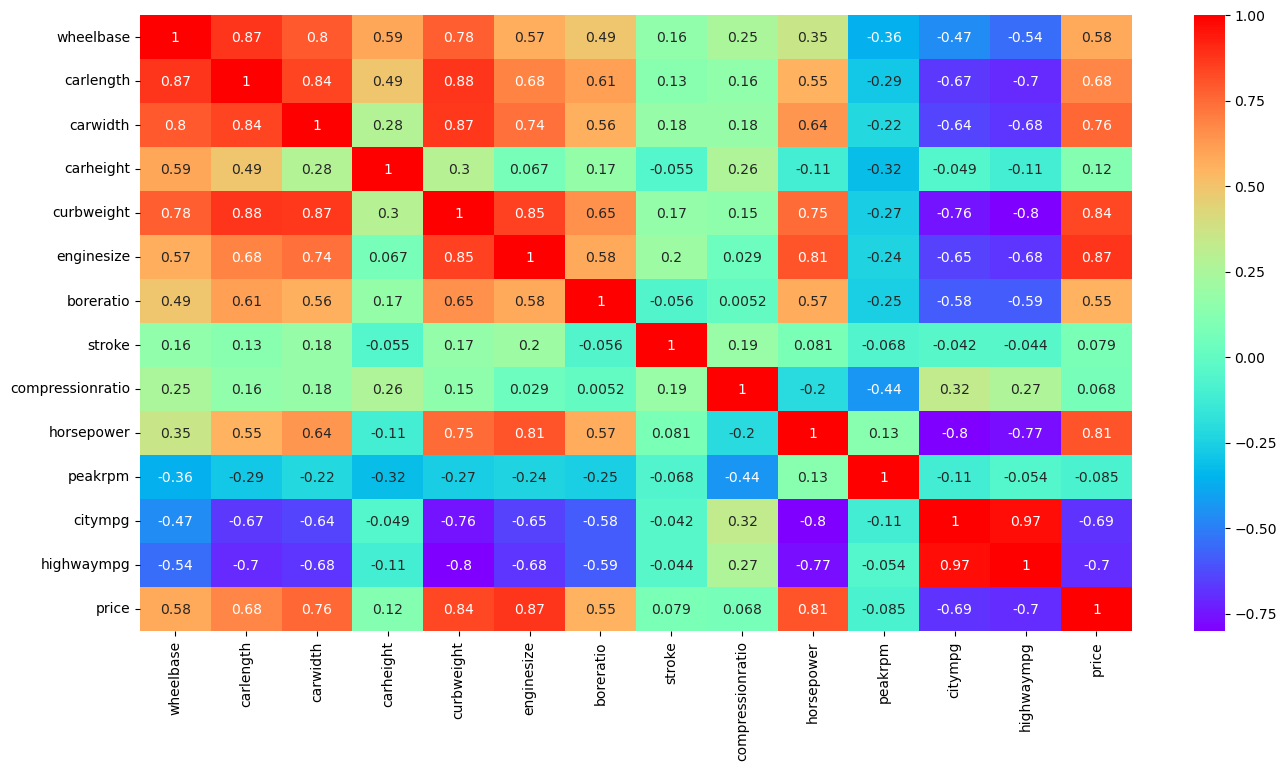

In [483]:
numeric_var=data.select_dtypes(include=["int","float"])
numeric_var
numeric_var= numeric_var.drop(['symboling','car_ID'], axis=1)
cor = numeric_var.corr()
print(cor)
plt.figure(figsize=(16,8))
sns.heatmap(cor,cmap="rainbow",annot=True)

Correlation of price with independent variables:

Price is highly (positively) correlated with wheelbase, carlength, carwidth, curbweight, enginesize, horsepower (notice how all of these variables represent the size/weight/engine power of the car)

Price is negatively correlated to citympg and highwaympg (-0.70 approximately). This suggest that cars having high mileage may fall in the 'economy' cars category, and are priced lower (think Maruti Alto/Swift type of cars, which are designed to be affordable by the middle class, who value mileage more than horsepower/size of car etc.)

Correlation among independent variables:

Many independent variables are highly correlated (look at the top-left part of matrix): wheelbase, carlength, curbweight, enginesize etc. are all measures of 'size/weight', and are positively correlated
Thus, while building the model, we'll have to pay attention to multicollinearity (especially linear models, such as linear  regression, suffer more from multicollinearity).

In [485]:
data.drop("car_ID",axis=1,inplace=True)
data

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,-1,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,-1,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,-1,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [487]:
categorical_vars= [ 'CarName', 'fueltype','aspiration','doornumber','carbody','drivewheel','enginelocation','enginetype','cylindernumber','fuelsystem']

label_encoders = {}
for col in categorical_vars:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str)) 
data["symboling"]=data["symboling"].replace([-1,-2],[4,5])
data["symboling"].value_counts()

symboling
0    67
1    54
2    32
3    27
4    22
5     3
Name: count, dtype: int64

Using label encoding we encoded the categorical variables.

In [489]:

data["price"]=np.log(data["price"])
data

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,0,1,0,1,0,2,0,88.6,168.8,...,130,5,3.47,2.68,9.0,111,5000,21,27,9.510075
1,3,0,1,0,1,0,2,0,88.6,168.8,...,130,5,3.47,2.68,9.0,111,5000,21,27,9.711116
2,1,0,1,0,1,2,2,0,94.5,171.2,...,152,5,2.68,3.47,9.0,154,5000,19,26,9.711116
3,2,1,1,0,0,3,1,0,99.8,176.6,...,109,5,3.19,3.40,10.0,102,5500,24,30,9.543235
4,2,1,1,0,0,3,0,0,99.4,176.6,...,136,5,3.19,3.40,8.0,115,5500,18,22,9.767095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,4,21,1,0,0,3,2,0,109.1,188.8,...,141,5,3.78,3.15,9.5,114,5400,23,28,9.731809
201,4,21,1,1,0,3,2,0,109.1,188.8,...,141,5,3.78,3.15,8.7,160,5300,19,25,9.854560
202,4,21,1,0,0,3,2,0,109.1,188.8,...,173,5,3.58,2.87,8.8,134,5500,18,23,9.975110
203,4,21,0,1,0,3,2,0,109.1,188.8,...,145,3,3.01,3.40,23.0,106,4800,26,27,10.019936


In [491]:
X = data.drop('price', axis=1)
Y = data['price']
X
Y

0       9.510075
1       9.711116
2       9.711116
3       9.543235
4       9.767095
         ...    
200     9.731809
201     9.854560
202     9.975110
203    10.019936
204    10.026811
Name: price, Length: 205, dtype: float64

In [493]:
# Step 2: Keep only numeric columns (after encoding)
X = X.select_dtypes(include='number')

# Step 3: Add constant column for intercept
X_const = add_constant(X)

# Step 4: Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i + 1) for i in range(len(X.columns))]

# Step 5: Display the result
print(vif_data.sort_values(by='VIF', ascending=False))

             Feature         VIF
2           fueltype  109.400830
19  compressionratio   99.981333
22           citympg   31.885629
23        highwaympg   28.076342
12        curbweight   19.075131
20        horsepower   14.634791
15        enginesize   14.232819
9          carlength   11.737231
8          wheelbase    9.655720
10          carwidth    8.745754
3         aspiration    3.359597
11         carheight    3.104580
21           peakrpm    2.772732
5            carbody    2.748900
6         drivewheel    2.631277
16        fuelsystem    2.599887
17         boreratio    2.542344
4         doornumber    2.360322
14    cylindernumber    2.203332
7     enginelocation    1.752103
18            stroke    1.667872
1            CarName    1.660522
13        enginetype    1.591941
0          symboling    1.455719


VIF > 10: Severe multicollinearity — e.g., fueltype, compressionratio , citympg, highwaympg.

VIF 5–10: Moderate multicollinearity — e.g., wheelbase,carwidth.

VIF < 5: Low multicollinearity — safe to keep.

Ridge Regression is suitable as it handles multicollinearity .


In [502]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, 
                                                    train_size=0.7,
                                                    test_size = 0.3, random_state=100)

In [504]:

X_train[['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg']]=np.log1p(X_train[['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg']])
X_train.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
122,1,14,1,0,0,3,1,0,4.550714,5.125748,...,2,4.595120,1,1.378766,1.442202,2.341806,4.234107,8.612685,3.465736,3.663562
125,3,15,1,0,1,2,2,0,4.559126,5.135210,...,2,5.023881,5,1.597365,1.413423,2.351375,4.969813,8.612685,2.995732,3.332205
166,1,19,1,0,1,2,2,0,4.559126,5.134032,...,2,4.595120,5,1.444563,1.406097,2.341806,4.727388,8.794976,3.295837,3.401197
1,3,0,1,0,1,0,2,0,4.495355,5.134621,...,2,4.875197,5,1.497388,1.302913,2.302585,4.718499,8.517393,3.091042,3.332205
199,4,21,1,1,0,4,2,0,4.656813,5.245971,...,2,4.875197,5,1.530395,1.423108,2.140066,5.093750,8.537192,2.890372,3.135494


In [506]:
X_test[['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg']]=np.log1p(X_test[['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg']])
X_test.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
160,0,19,1,0,0,3,1,0,4.571613,5.119789,...,2,4.595120,1,1.432701,1.393766,2.302585,4.262680,8.476580,3.663562,3.871201
186,2,20,1,0,0,3,1,0,4.588024,5.151556,...,2,4.700480,5,1.432701,1.481605,2.302585,4.454347,8.566174,3.332205,3.555348
59,1,9,1,0,1,2,1,0,4.603168,5.186268,...,2,4.812184,1,1.479329,1.479329,2.261763,4.442651,8.476580,3.295837,3.496508
165,1,19,1,0,1,3,2,0,4.559126,5.134032,...,2,4.595120,5,1.444563,1.406097,2.341806,4.727388,8.794976,3.295837,3.401197
140,2,18,1,0,1,2,0,0,4.546481,5.064492,...,2,4.691348,1,1.530395,1.291984,2.272126,4.304065,8.389587,3.295837,3.465736


In [534]:
ridge = Ridge(alpha=1.0)  # You can tune alpha
ridge.fit(X_train, y_train)

# 📈 Predictions
y_pred = ridge.predict(X_test)

# 📊 Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("Coefficients:", ridge.coef_)
print("MAE",mean_absolute_error(y_test,y_pred))

MSE: 0.026750804844340916
R² Score: 0.8878450261398763
Coefficients: [ 0.01805716 -0.01242337 -0.10552347 -0.04294269 -0.06894243 -0.00372772
  0.08112331  0.22964385  0.11995455  0.12337529  0.11008231  0.11114885
  0.40910186  0.00690448 -0.0040242   0.27289647  0.02924276  0.07498311
 -0.12269616  0.23503584  0.36581892 -0.00478718 -0.26823061 -0.16329895]
MAE 0.12931425194809867


Here R^2 suggests 89% proportion of variation is explained by regressor variables.

For using Ridge regression we saw we get a small MSE and MAE, it suggest that the model fitted well.

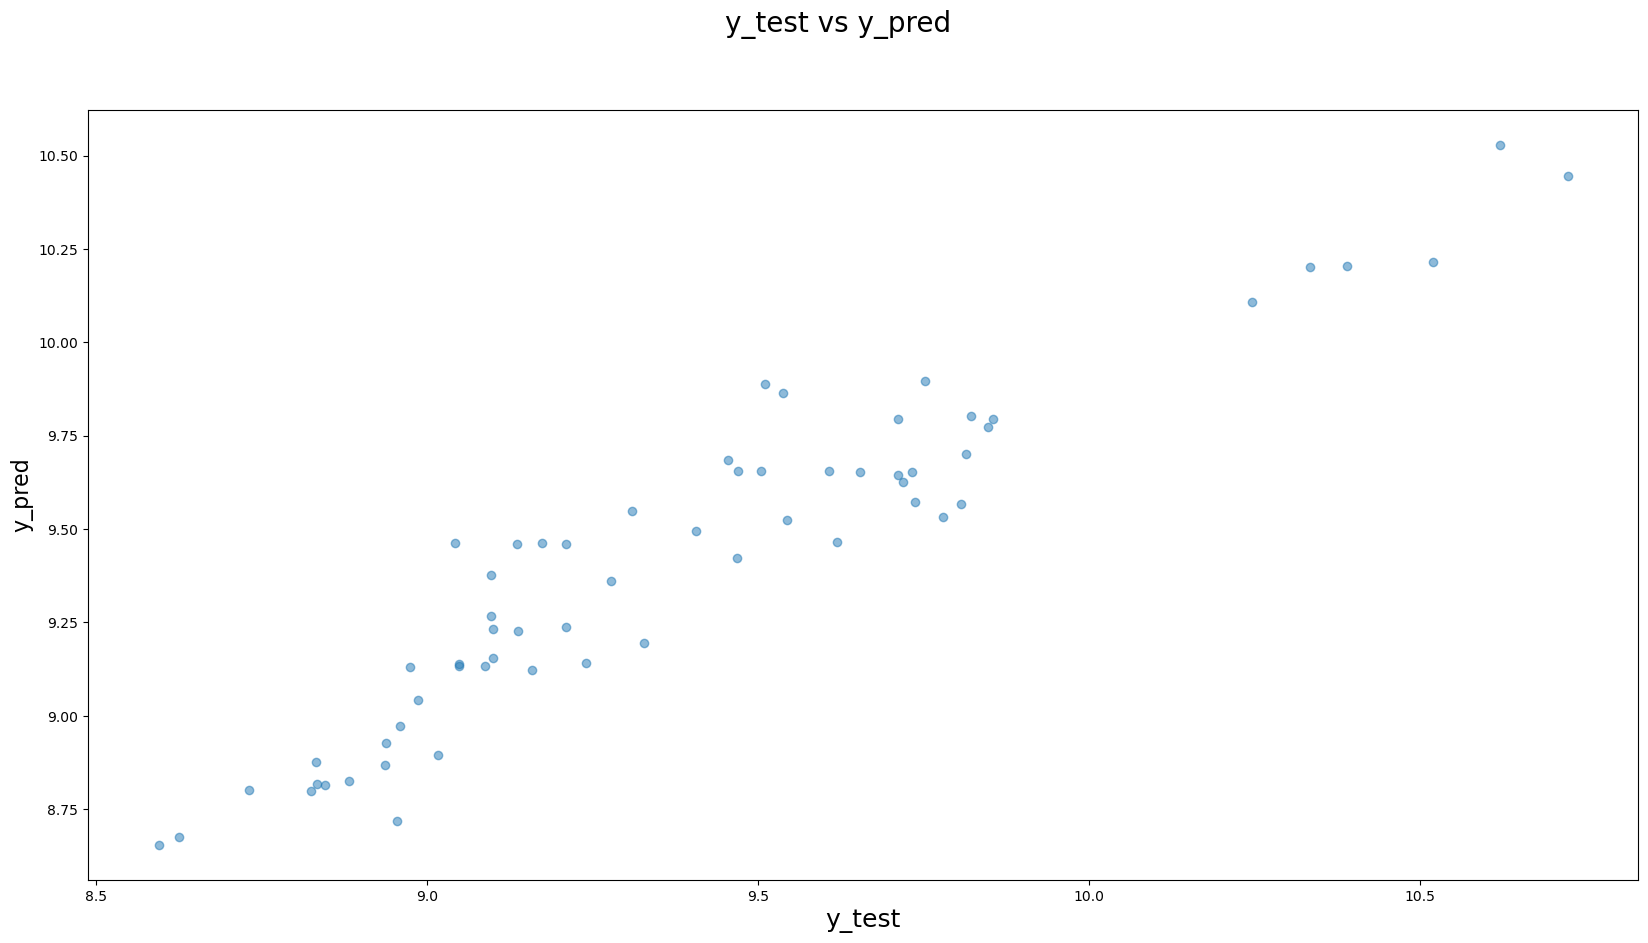

In [511]:
fig = plt.figure(figsize=(20,10))
plt.scatter(y_test, y_pred, alpha=.5)
fig.suptitle('y_test vs y_pred', fontsize = 20)              
plt.xlabel('y_test', fontsize = 18)                          
plt.ylabel('y_pred', fontsize = 16) 
plt.show()

In [513]:
df= pd.DataFrame({'Actual':y_test,'Predictions':y_pred})
df['Predictions']= round(df['Predictions'],2)
df.head()

,Actual,Predictions
160,8.953899,8.72
186,9.047233,9.13
59,9.087608,9.13
165,9.137555,9.23
140,8.936298,8.87


In [515]:
y_test_log = y_test      
y_pred_log = y_pred      


y_test_exp = np.exp(y_test_log)
y_pred_exp = np.exp(y_pred_log)


Convert the  dataframe into original scale.

In [518]:
df= pd.DataFrame({'Actual':y_test_exp,'Predictions':y_pred_exp})
df['Predictions']= round(df['Predictions'],2)
df.head()

,Actual,Predictions
160,7738.0,6114.79
186,8495.0,9267.75
59,8845.0,9264.53
165,9298.0,10180.95
140,7603.0,7108.31


In [520]:
lasso = Lasso(alpha=0.1)  # Tune alpha as needed
lasso.fit(X_train, y_train)

# 🔹 Predict
y_pred = lasso.predict(X_test)

# 🔹 Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("Lasso Coefficients:", lasso.coef_)
print("MAE",mean_absolute_error(y_test,y_pred))

MSE: 0.12297783917095505
R² Score: 0.4844051826533827
Lasso Coefficients: [ 0.         -0.01630477 -0.          0.         -0.          0.
  0.02510731  0.          0.          0.          0.          0.
  0.         -0.          0.          0.          0.14349878  0.
  0.          0.          0.         -0.         -0.         -0.        ]
MAE 0.26185505685282223


Here R^2 suggests 48% proportion of variation is explained by regressor variables.


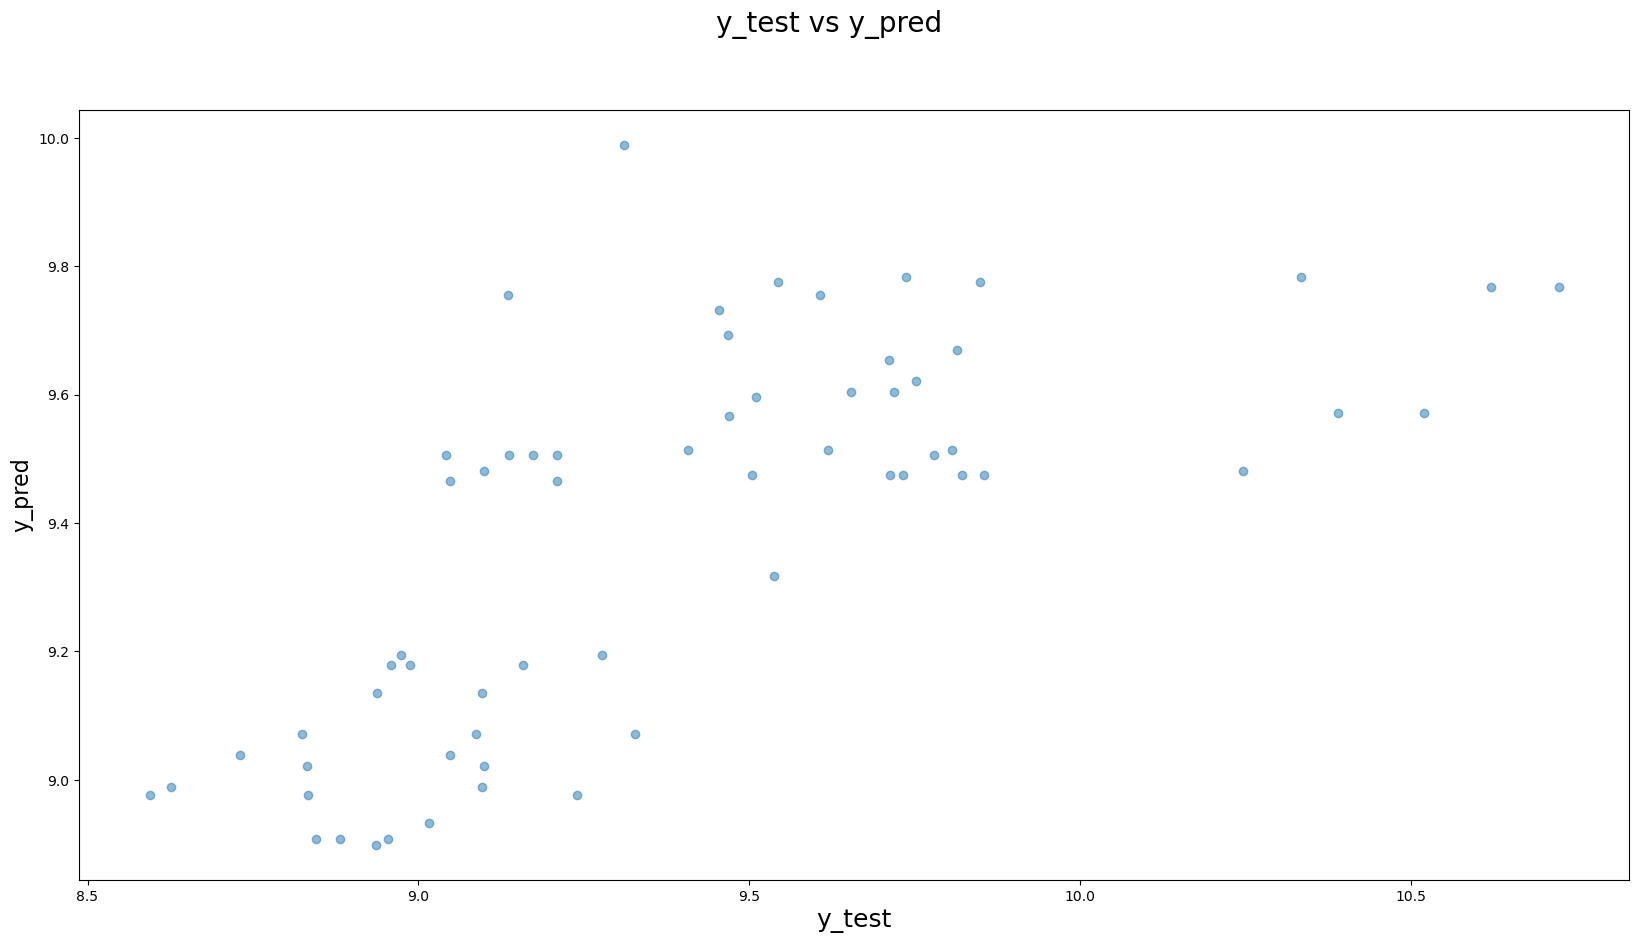

In [522]:
fig = plt.figure(figsize=(20,10))
plt.scatter(y_test, y_pred, alpha=.5)
fig.suptitle('y_test vs y_pred', fontsize = 20)               
plt.xlabel('y_test', fontsize = 18)                          
plt.ylabel('y_pred', fontsize = 16) 
plt.show()

In [524]:
df= pd.DataFrame({'Actual':y_test,'Predictions':y_pred})
df['Predictions']= round(df['Predictions'],2)
df.head()

,Actual,Predictions
160,8.953899,8.91
186,9.047233,9.47
59,9.087608,9.07
165,9.137555,9.51
140,8.936298,8.90


In [526]:
y_test_log = y_test      
y_pred_log = y_pred      


y_test_exp = np.exp(y_test_log)
y_pred_exp = np.exp(y_pred_log)

Convert the  dataframe into original scale.

In [531]:
df= pd.DataFrame({'Actual':y_test_exp,'Predictions':y_pred_exp})
df['Predictions']= round(df['Predictions'],2)
df.head()

,Actual,Predictions
160,7738.0,7388.48
186,8495.0,12904.96
59,8845.0,8696.92
165,9298.0,13450.61
140,7603.0,7323.73


*Conclusion*

We compare this two model Ridge and Lasso with some metrics R^2,MSE,MAE. we saw Ridge regression is very much better than Lasso regression.

Now we check that Ridge regression is follows my assumption or not.

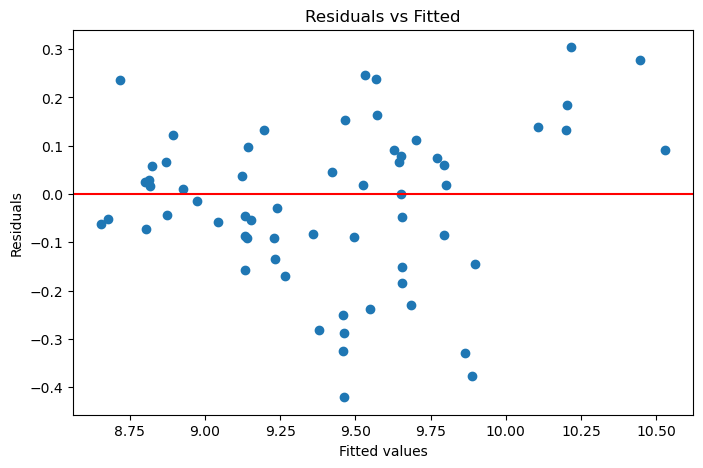

In [536]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

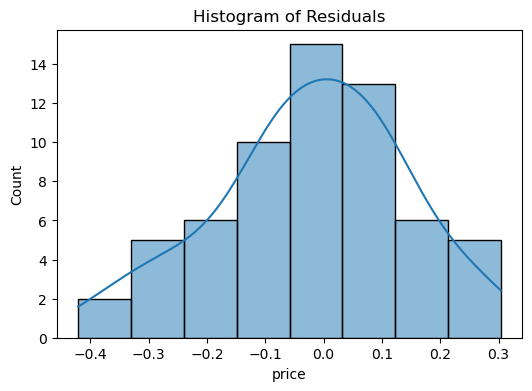

In [538]:
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.show()

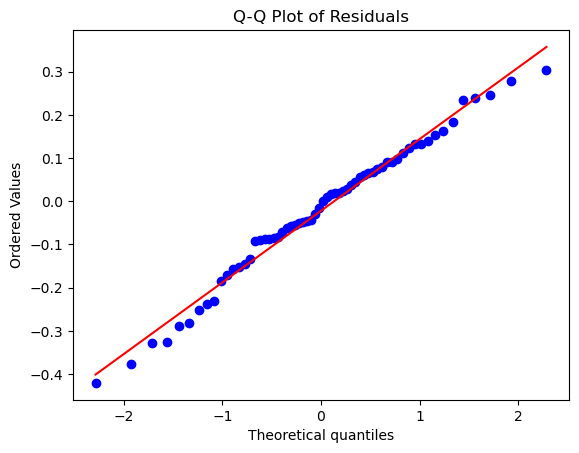

In [540]:
probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

The residuals vs fitted plot shows a random scatter around zero, indicating that the assumptions of linearity and constant variance are satisfied for the Ridge regression model.

The histogram shows a bell-shaped, symmetric distribution centered around zero. This indicates that the residuals are approximately normally distributed, with no significant skewness or heavy tails.

The Q-Q plot shows that most of the residuals lie close to the reference line, with only minor deviations at the tails. This further confirms that the residuals follow a nearly normal distribution.

Both the histogram and the Q-Q plot suggest that the **normality assumption of residuals is well satisfied**, making the linear(Ridge) regression model appropriate for inference.
